# Homework 9

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

## 1. Load and split dataset

In [10]:
df = pd.read_excel('../data_polymerization.xlsx')
df = df.sort_values('Date.Time').reset_index(drop=True)   # ensure temporal order

y = df['Quality'].values
X = df.drop(columns=['Quality', 'Date.Time'])             # drop target and timestamp
feature_names = X.columns.tolist()
X = X.values

# time-based hold-out: the LAST 10% of the series is the test set
n = len(df)
cut = int(n * 0.90)
X_trval, X_test = X[:cut], X[cut:]
y_trval, y_test = y[:cut], y[cut:]
print(f'train+val: {X_trval.shape[0]} samples (until {df["Date.Time"].iloc[cut-1]})')
print(f'test:      {X_test.shape[0]} samples (from {df["Date.Time"].iloc[cut]})')

train+val: 2437 samples (until 2017-05-04 14:59:00)
test:      271 samples (from 2017-05-04 16:01:00)


## 2. Time-series cross-validation

`TimeSeriesSplit` produces expanding-window folds: each validation block lies strictly after its training block, so the model is never trained on data from the future of its validation set.

In [11]:
tscv = TimeSeriesSplit(n_splits=5)

# print the fold structure to confirm train always precedes validation in time
for i, (tr, va) in enumerate(tscv.split(X_trval)):
    print(f'fold {i}: train [0:{tr[-1]+1}]  validate [{va[0]}:{va[-1]+1}]')

fold 0: train [0:407]  validate [407:813]
fold 1: train [0:813]  validate [813:1219]
fold 2: train [0:1219]  validate [1219:1625]
fold 3: train [0:1625]  validate [1625:2031]
fold 4: train [0:2031]  validate [2031:2437]


## 3. Decision Tree: Hyperparameter Tuning

We tune the parameters controlling tree complexity / pruning: `max_depth`, `min_samples_leaf`, `min_samples_split`. Scoring is negative RMSE.

In [12]:
# hyperparameters controlling tree complexity
dt_grid = {
    'max_depth':         [3, 5, 8, 12, None],   # None means grow until pure leaves
    'min_samples_leaf':  [1, 5, 10, 20],        # larger -> smoother, fewer tiny leaves
    'min_samples_split': [2, 10, 20],           # min samples required to split an internal node
}
dt_gs = GridSearchCV(DecisionTreeRegressor(random_state=0),
                     dt_grid, cv=tscv,
                     scoring='neg_root_mean_squared_error', n_jobs=-1)
dt_gs.fit(X_trval, y_trval)
print('DT best params:', dt_gs.best_params_)
print(f'DT best CV RMSE = {-dt_gs.best_score_:.4f}')

DT best params: {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2}
DT best CV RMSE = 1.8661


## 4. Random Forest: Hyperparameter Tuning

A forest averages many decorrelated trees. Key hyperparameters: number of trees `n_estimators`, tree depth, `max_features` and `min_samples_leaf`.

In [13]:
# forest is the average of many decorrelated trees
rf_grid = {
    'n_estimators':     [100, 300],         # number of trees in the ensemble
    'max_depth':        [5, 10, None],      # depth of each individual tree
    'max_features':     [0.33, 0.66, 1.0],  # fraction of features tried per split
    'min_samples_leaf': [1, 5],             # leaf-size floor for regularization
}
rf_gs = GridSearchCV(RandomForestRegressor(random_state=0, n_jobs=-1),
                     rf_grid, cv=tscv,
                     scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_gs.fit(X_trval, y_trval)
print('RF best params:', rf_gs.best_params_)
print(f'RF best CV RMSE = {-rf_gs.best_score_:.4f}')

RF best params: {'max_depth': None, 'max_features': 0.66, 'min_samples_leaf': 5, 'n_estimators': 100}
RF best CV RMSE = 1.5081


## 5. Evaluation on the independent (future) test set

In [14]:
def evaluate(model, name):
    yp = model.predict(X_test)
    print(f'{name:15s} RMSE={root_mean_squared_error(y_test, yp):.4f}  '
          f'MAE={mean_absolute_error(y_test, yp):.4f}  R2={r2_score(y_test, yp):.4f}')
    return yp

print('Independent test-set performance:')
y_dt = evaluate(dt_gs.best_estimator_, 'Decision Tree')
y_rf = evaluate(rf_gs.best_estimator_, 'Random Forest')

Independent test-set performance:
Decision Tree   RMSE=2.4733  MAE=1.2878  R2=0.5239
Random Forest   RMSE=1.6545  MAE=0.6951  R2=0.7870


## 6. Feature importance (Random Forest)

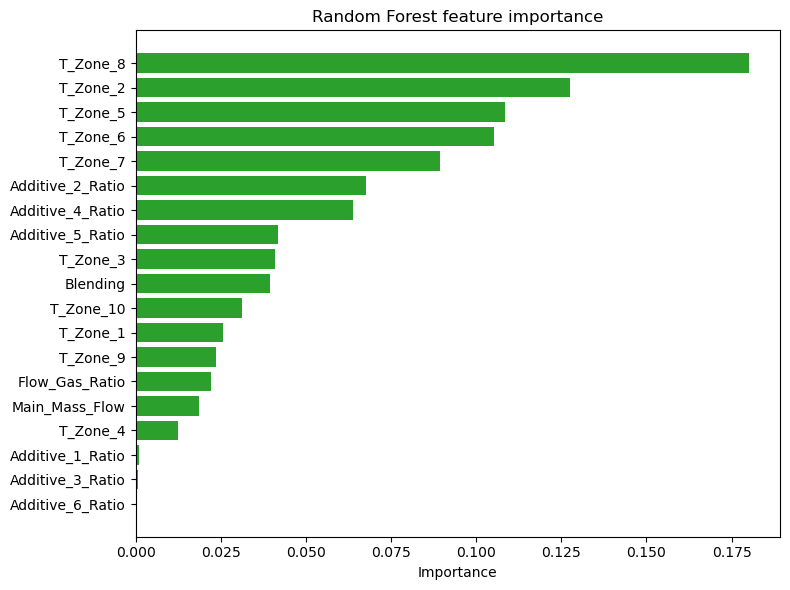

In [15]:
# impurity-based importances from the tuned forest, sorted ascending for a horizontal bar chart
imp = pd.Series(rf_gs.best_estimator_.feature_importances_, index=feature_names)
imp = imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp.index, imp.values, color='tab:green')
ax.set_xlabel('Importance'); ax.set_title('Random Forest feature importance')
plt.tight_layout(); plt.show()

## 7. Predicted vs. actual over the test period

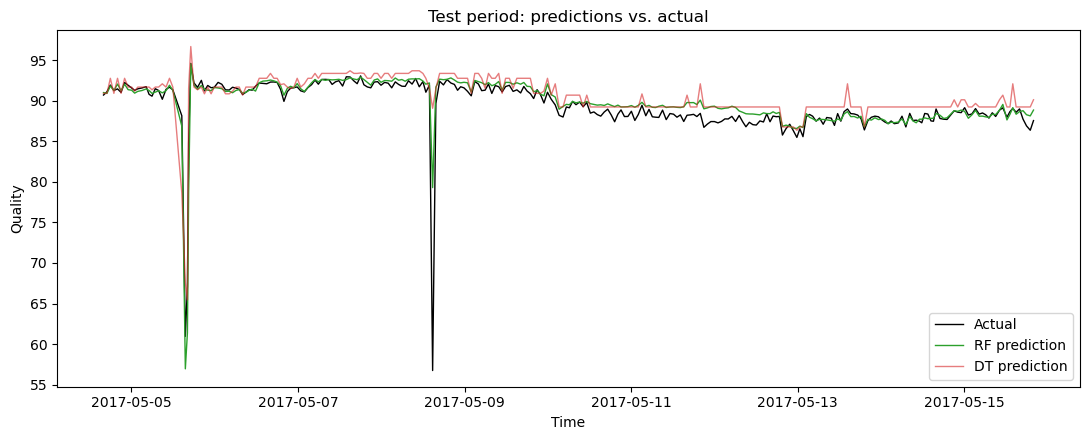

In [16]:
t_test = df['Date.Time'].iloc[cut:].values  # timestamps of the test block (x-axis)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_test, y_test, label='Actual', color='k', lw=1)
ax.plot(t_test, y_rf, label='RF prediction', color='tab:green', lw=1)   # ground truth over time
ax.plot(t_test, y_dt, label='DT prediction', color='tab:red', lw=1, alpha=0.6)
ax.set_xlabel('Time'); ax.set_ylabel('Quality')
ax.set_title('Test period: predictions vs. actual')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Discussion

### Results

| Model | Best CV RMSE | Test RMSE | Test MAE | Test R² |
|---|---|---|---|---|
| Decision Tree | ≈ 1.87 | ≈ 2.47 | ≈ 1.29 | ≈ 0.52 |
| Random Forest | ≈ 1.51 | ≈ 1.65 | ≈ 0.70 | ≈ 0.79 |

Random Forest clearly outperforms the single tree on the future test set (R² 0.79 vs 0.52, roughly half the RMSE). This is the expected result, because a single tree is high-variance and sensitive to outliers, while averaging many decorrelated trees reduces variance and yields a smoother, more robust response surface. The plot of predictions over the test period shows the RF tracking the actual `Quality` closely, while the DT is noticeably jumpier.

### Hyperparameters
- Decision Tree selected a fairly deep tree (`max_depth ≈ 12`). Even so it generalizes worse: its CV RMSE (1.87) is much smaller than its test RMSE (2.47), the classic sign of a single tree overfitting and degrading on unseen future data.
- Random Forest preferred `max_features ≈ 0.66` and a small leaf size with little benefit beyond 100 trees. Limiting `max_features` is what decorrelates the trees and drives the variance reduction.

### Quality
The importance ranking is dominated by the temperature zones (`T_Zone_8`, `T_Zone_2`, `T_Zone_5`, `T_Zone_6`, `T_Zone_7`), followed by some additive ratios. Process temperature is the main influence on product quality here, which is a physically plausible finding.

### Time-dependence
Because the test block is the chronological future, the test error also absorbs any drift in the process between training and test periods, which is why test R² (0.79) sits below the CV figure. This is the honest generalization estimate for a deployed model that must predict forward in time. Had we used a random split and shuffled k-fold, both models would have looked artificially better by borrowing information from future rows, which is exactly the leakage the time-series methodology is designed to prevent.

### Limitations
- One `Quality` value is a gross outlier (≈ −5 vs. a mean of ≈ 90). A single tree can isolate such a point in its own leaf, the forest mitigates this by averaging, another reason the RF is more reliable here.
- The forest's gain in accuracy comes at the cost of interpretability: unlike OLS/LASSO coefficients, importances show which variables matter but not the direction or shape of their effect.